# Notebook 02 — Lesion-focused images

This notebook loads the segmenter trained in
[`01_segmentation.ipynb`](01_segmentation.ipynb) and turns raw images into
**lesion-focused** images: every pixel outside the predicted lesion mask is
replaced with white. These are exactly the *lesion-only* inputs compared
against full-image inputs in the report.

All real logic lives in [`src/segmentation_unet.py`](../src/segmentation_unet.py).

## Setup

Same `SAMPLE` switch as notebook 01. **Run notebook 01 first** — this notebook
reads the checkpoint it wrote.

In [1]:
# Notebook 02 — Lesion-focused images
# Inputs:  ../models/segmentation_unet_v2.pth        (from notebook 01)
#          ../data/sample/ham10000/images            (SAMPLE=True)
#          ../data/ham10000/images                   (SAMPLE=False, edit below)
# Outputs: ../data/lesion-focused-sample/{images,masks}
#          ../figures/lesion_focused_examples.png
# Runtime: a few seconds on CPU in SAMPLE mode
import sys; sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm

from segmentation_unet import SimpleUNet, predict_lesion_mask, composite_on_white

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({"font.size": 10, "figure.dpi": 100})

SAMPLE = True                 # <-- keep in sync with notebook 01
IMAGE_SIZE = 128 if SAMPLE else 256
THRESHOLD = 0.5

if SAMPLE:
    SOURCE_IMAGE_DIR = "../data/sample/ham10000/images"
    OUTPUT_ROOT      = "../data/lesion-focused-sample"
else:
    SOURCE_IMAGE_DIR = "../data/ham10000/images"   # edit to your real path
    OUTPUT_ROOT      = "../data/lesion-focused"

CKPT_PATH = "../models/segmentation_unet_v2.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"SAMPLE={SAMPLE}  device={device}  image_size={IMAGE_SIZE}")

SAMPLE=True  device=cpu  image_size=128


## Load the trained segmenter

If the checkpoint is missing, run notebook 01 first.

In [2]:
if not Path(CKPT_PATH).exists():
    raise FileNotFoundError(
        f"{CKPT_PATH} not found. Run 01_segmentation.ipynb first "
        f"(Restart Kernel & Run All)."
    )
model = SimpleUNet().to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
model.eval()

image_files = sorted(f for f in Path(SOURCE_IMAGE_DIR).iterdir() if f.suffix == ".jpg")
print(f"Loaded segmenter; {len(image_files)} source images in {SOURCE_IMAGE_DIR}")

Loaded segmenter; 12 source images in ../data/sample/ham10000/images


## One example, step by step

For a single image we (1) predict and clean the lesion mask, then (2)
composite the original over a white background:

$$\tilde{x}_{ijk} = m_{ij}\, x_{ijk} + (1 - m_{ij})\cdot 255.$$

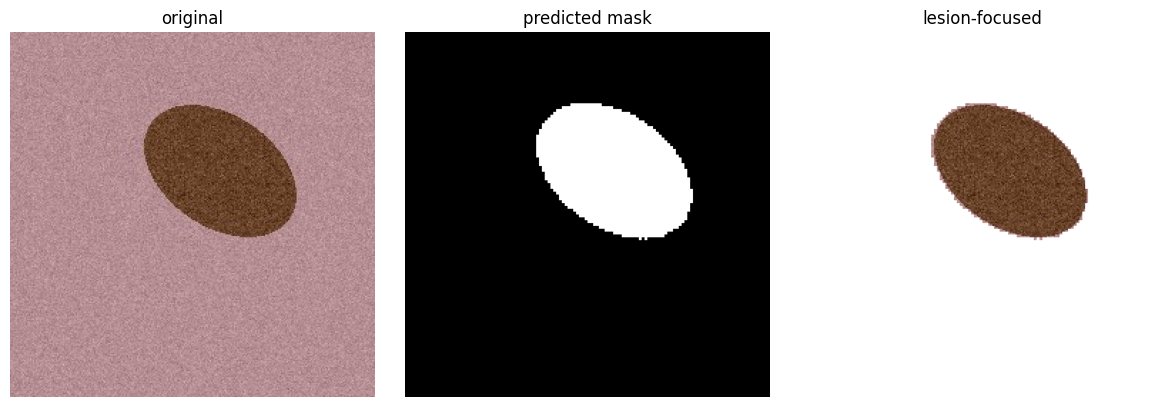

In [3]:
example = Image.open(image_files[0]).convert("RGB")
mask = predict_lesion_mask(model, example, device, image_size=IMAGE_SIZE, threshold=THRESHOLD)
focused = composite_on_white(example, mask)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(example);          ax[0].set_title("original");        ax[0].axis("off")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("predicted mask"); ax[1].axis("off")
ax[2].imshow(focused);          ax[2].set_title("lesion-focused");  ax[2].axis("off")
plt.tight_layout(); plt.show()

## Generate lesion-focused images for every source image

We write the lesion-focused image and its mask to `OUTPUT_ROOT`. This is the
preprocessing step that produces the *lesion-only* classifier inputs used in
the report (there, at scale, with the DeepLabV3 segmenter).

In [4]:
img_out = Path(OUTPUT_ROOT) / "images"
mask_out = Path(OUTPUT_ROOT) / "masks"
img_out.mkdir(parents=True, exist_ok=True)
mask_out.mkdir(parents=True, exist_ok=True)

for path in tqdm(image_files, desc="lesion-focusing"):
    image = Image.open(path).convert("RGB")
    mask = predict_lesion_mask(model, image, device, image_size=IMAGE_SIZE, threshold=THRESHOLD)
    composite_on_white(image, mask).save(img_out / path.name)
    Image.fromarray((mask * 255).astype(np.uint8)).save(mask_out / f"{path.stem}_mask.png")

print(f"Wrote {len(image_files)} lesion-focused images to {img_out}")
print(f"Wrote {len(image_files)} masks to {mask_out}")

lesion-focusing:   0%|          | 0/12 [00:00<?, ?it/s]

lesion-focusing:  17%|█▋        | 2/12 [00:00<00:00, 15.87it/s]

lesion-focusing:  33%|███▎      | 4/12 [00:00<00:00, 17.73it/s]

lesion-focusing:  58%|█████▊    | 7/12 [00:00<00:00, 19.51it/s]

lesion-focusing:  75%|███████▌  | 9/12 [00:00<00:00, 19.36it/s]

lesion-focusing: 100%|██████████| 12/12 [00:00<00:00, 19.40it/s]

lesion-focusing: 100%|██████████| 12/12 [00:00<00:00, 19.02it/s]

Wrote 12 lesion-focused images to ../data/lesion-focused-sample/images
Wrote 12 masks to ../data/lesion-focused-sample/masks


## Gallery

A random (seeded) sample of original / mask / lesion-focused triples read back
from disk, to confirm the saved files are correct.

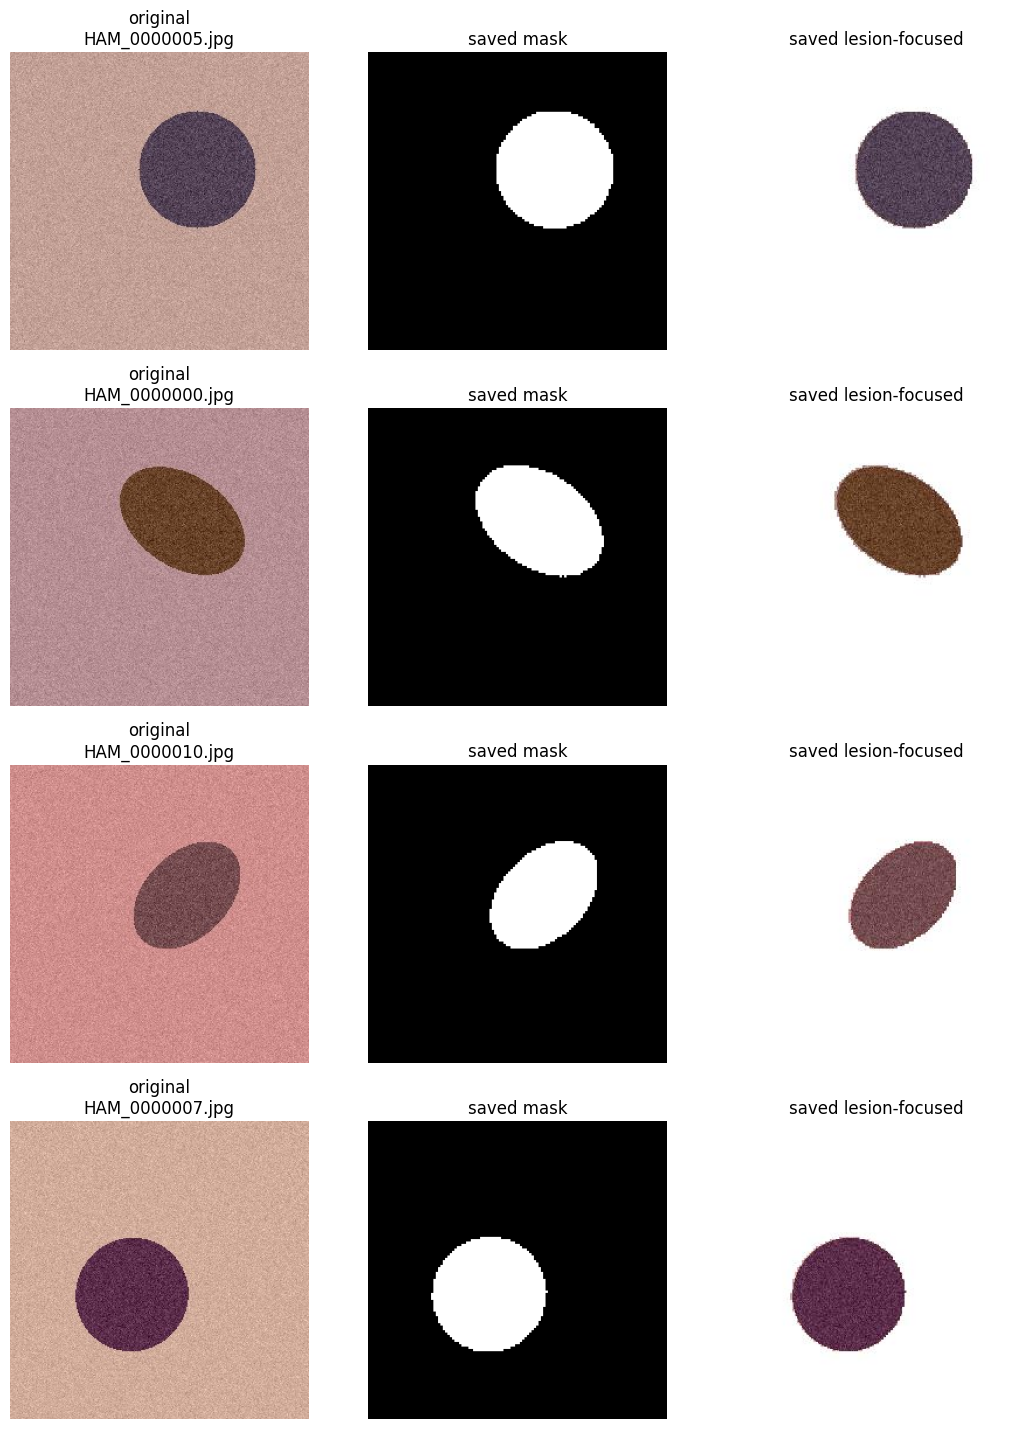

In [5]:
sample = rng.choice(len(image_files), size=min(4, len(image_files)), replace=False)
fig, ax = plt.subplots(len(sample), 3, figsize=(11, 3.6 * len(sample)))
ax = np.atleast_2d(ax)
for row, idx in enumerate(sample):
    name = image_files[idx].name
    orig = Image.open(image_files[idx]).convert("RGB")
    msk  = Image.open(mask_out / f"{Path(name).stem}_mask.png").convert("L")
    foc  = Image.open(img_out / name).convert("RGB")
    ax[row, 0].imshow(orig); ax[row, 0].set_title(f"original\n{name}")
    ax[row, 1].imshow(msk, cmap="gray"); ax[row, 1].set_title("saved mask")
    ax[row, 2].imshow(foc); ax[row, 2].set_title("saved lesion-focused")
    for j in range(3): ax[row, j].axis("off")
plt.tight_layout()
Path("../figures").mkdir(exist_ok=True)
plt.savefig("../figures/lesion_focused_examples.png", bbox_inches="tight")
plt.show()

**Takeaway.** The pipeline turns each raw image into a background-suppressed
lesion-focused image. In the full study this transformation is applied to all
of HAM10000 and PAD-UFES-20 (with the DeepLabV3 segmenter), and matched
classifiers are trained on full-image vs. lesion-focused inputs — see
`src/` and the report.